## Objective
This project builds a simplified rule-based scoring tool to predict blood-brain barrier (BBB) permeability of small molecules, based on molecular descriptors commonly used in CNS drug design (MW, LogP, TPSA, HBD). The tool is validated against a small set of known CNS-active and non-CNS drugs.


## Method
Molecular descriptors (molecular weight, LogP, TPSA, hydrogen bond donors) were computed using RDKit from each molecule's SMILES string. A simplified CNS Multiparameter Optimization (MPO) scoring function, adapted from Wager et al. (2010), was applied to generate a composite score (0–4) for each molecule.

import csv
with open('molecules.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        print(row['Name'], row['category'])

In [5]:
with open('molecules.csv') as f:
    print(f.readline())

Name, category, smiles



In [7]:
import csv
with open('molecules.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        print(row['Name'], row['category'])

Diazepam CNS
Fluoxetine CNS
Donepezil CNS
Caffeine CNS
Morphine CNS
Carbamazepine CNS
Haloperidol CNS
Atenolol CNS
Cetirizine CNS
Loperamide CNS
Furosemide CNS
Metformin CNS


In [9]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import csv

with open('molecules.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        mol = Chem.MolFromSmiles(row['smiles'])
        
        if mol is None:
            print(row['Name'], "- INVALID SMILES, check this one")
            continue
        
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        
        print(row['Name'], row['category'], "| MW:", round(mw,2), "LogP:", round(logp,2), 
              "TPSA:", round(tpsa,2), "HBD:", hbd, "HBA:", hba)

Diazepam CNS | MW: 284.75 LogP: 3.15 TPSA: 32.67 HBD: 0 HBA: 2
Fluoxetine CNS | MW: 309.33 LogP: 4.44 TPSA: 21.26 HBD: 1 HBA: 2
Donepezil CNS | MW: 379.5 LogP: 4.36 TPSA: 38.77 HBD: 0 HBA: 4
Caffeine CNS | MW: 194.19 LogP: -1.03 TPSA: 61.82 HBD: 0 HBA: 3
Morphine CNS | MW: 285.34 LogP: 1.2 TPSA: 52.93 HBD: 2 HBA: 4
Carbamazepine CNS | MW: 236.27 LogP: 3.39 TPSA: 46.33 HBD: 1 HBA: 1
Haloperidol CNS | MW: 375.87 LogP: 4.43 TPSA: 40.54 HBD: 1 HBA: 3
Atenolol CNS | MW: 266.34 LogP: 0.45 TPSA: 84.58 HBD: 3 HBA: 4
Cetirizine CNS | MW: 388.9 LogP: 3.15 TPSA: 53.01 HBD: 1 HBA: 4
Loperamide CNS | MW: 477.05 LogP: 5.09 TPSA: 43.78 HBD: 1 HBA: 3
Furosemide CNS | MW: 330.75 LogP: 1.89 TPSA: 122.63 HBD: 3 HBA: 5
Metformin CNS | MW: 129.17 LogP: -1.24 TPSA: 91.49 HBD: 3 HBA: 1


In [17]:
def cns_score(mw, logp, tpsa, hbd):
    score = 0
    # Molecular weight
    if mw < 360:
        score += 1
    elif mw < 500:
        score += 0.5
    # LogP
    if 2 <= logp <= 4:
        score += 1
    else:
        score += 0.5
    # TPSA
    if 40 <= tpsa <= 90:
        score += 1
    else:
        score += 0.5
    # H-bond donors
    if hbd <= 0.5:
        score += 1
    elif hbd <= 1:
        score += 0.5
    return score

In [13]:
results = []

with open('molecules.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is None:
            continue
        
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        score = cns_score(mw, logp, tpsa, hbd)
        
        results.append({
            'name': row['Name'],
            'category': row['category'],
            'mw': round(mw,2),
            'logp': round(logp,2),
            'tpsa': round(tpsa,2),
            'hbd': hbd,
            'hba': hba,
            'cns_score': score
        })

for r in results:
    print(r['name'], "|", r['category'], "| Score:", r['cns_score'])

Diazepam | CNS | Score: 3.5
Fluoxetine | CNS | Score: 2.5
Donepezil | CNS | Score: 2.5
Caffeine | CNS | Score: 3.5
Morphine | CNS | Score: 2.5
Carbamazepine | CNS | Score: 3.5
Haloperidol | CNS | Score: 2.5
Atenolol | CNS | Score: 2.5
Cetirizine | CNS | Score: 3.0
Loperamide | CNS | Score: 2.5
Furosemide | CNS | Score: 2.0
Metformin | CNS | Score: 2.0


In [14]:
with open('molecules.csv') as f:
    for line in f:
        print(line)
        

Name,category,smiles

Diazepam,CNS,CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3

Fluoxetine,CNS,CNCCC(C1=CC=CC=C1)OC2=CC=C(C=C2)C(F)(F)F

Donepezil,CNS,COC1=C(C=C2C(=C1)CC(C2=O)CC3CCN(CC3)CC4=CC=CC=C4)OC

Caffeine,CNS,CN1C=NC2=C1C(=O)N(C(=O)N2C)C

Morphine,CNS,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O

Carbamazepine,CNS,C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2C(=O)N

Haloperidol,CNS,C1CN(CCC1(C2=CC=C(C=C2)Cl)O)CCCC(=O)C3=CC=C(C=C3)F

Atenolol,CNS,CC(C)NCC(COC1=CC=C(C=C1)CC(=O)N)O

Cetirizine,CNS,C1CN(CCN1CCOCC(=O)O)C(C2=CC=CC=C2)C3=CC=C(C=C3)Cl

Loperamide,CNS,CN(C)C(=O)C(CCN1CCC(CC1)(C2=CC=C(C=C2)Cl)O)(C3=CC=CC=C3)C4=CC=CC=C4

Furosemide,CNS,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl

Metformin,CNS,CN(C)C(=N)N=C(N)N



In [15]:
results = []

with open('molecules.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is None:
            continue
        
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        score = cns_score(mw, logp, tpsa, hbd)
        
        results.append({
            'name': row['Name'],
            'category': row['category'],
            'mw': round(mw,2),
            'logp': round(logp,2),
            'tpsa': round(tpsa,2),
            'hbd': hbd,
            'hba': hba,
            'cns_score': score
        })

for r in results:
    print(r['name'], "|", r['category'], "| Score:", r['cns_score'])

Diazepam | CNS | Score: 3.5
Fluoxetine | CNS | Score: 2.5
Donepezil | CNS | Score: 2.5
Caffeine | CNS | Score: 3.5
Morphine | CNS | Score: 2.5
Carbamazepine | CNS | Score: 3.5
Haloperidol | CNS | Score: 2.5
Atenolol | nonCNS | Score: 2.5
Cetirizine | nonCNS | Score: 3.0
Loperamide | nonCNS | Score: 2.5
Furosemide | nonCNS | Score: 2.0
Metformin | nonCNS | Score: 2.0


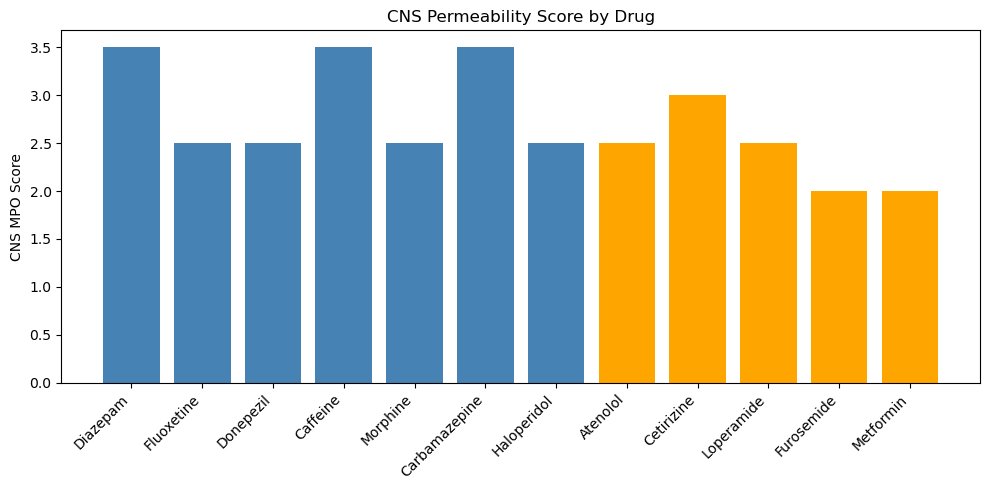

In [19]:
import matplotlib.pyplot as plt

names = [r['name'] for r in results]
scores = [r['cns_score'] for r in results]
colors = ['steelblue' if r['category']=='CNS' else 'orange' for r in results]

plt.figure(figsize=(10,5))
plt.bar(names, scores, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('CNS MPO Score')
plt.title('CNS Permeability Score by Drug')
plt.tight_layout()
plt.savefig('cns_chart.png' , dpi=150, bbox_inches='tight')
plt.show()
plt.show()

## Results

Across the twelve compounds tested, CNS-active drugs scored between 2.5 and 3.5 (mean ≈ 3.0), while non-CNS drugs scored between 2.0 and 3.0 (mean ≈ 2.4). The three highest scoring compounds overall — Diazepam, Caffeine, and Carbamazepine, all scoring 3.5 are all well established CNS active drugs, consistent with expectations.

However, the separation between groups was not complete. Cetirizine, a non CNS antihistamine specifically engineered to minimize brain penetration, scored 3.0 higher than four of the seven CNS active drugs in the dataset (Fluoxetine, Donepezil, Morphine, and Haloperidol, each scoring 2.5). This overlap indicates that while the scoring tool captures a general trend, it does not achieve clean separation between the two classes on this dataset.

| Category | Drug | CNS Score |
| CNS | Diazepam | 3.5 |
| CNS | Caffeine | 3.5 |
| CNS | Carbamazepine | 3.5 |
| CNS | Fluoxetine | 2.5 |
| CNS | Donepezil | 2.5 |
| CNS | Morphine | 2.5 |
| CNS | Haloperidol | 2.5 |
| Non-CNS | Cetirizine | 3.0 |
| Non-CNS | Atenolol | 2.5 |
| Non-CNS | Loperamide | 2.5 |
| Non-CNS | Furosemide | 2.0 |
| Non-CNS | Metformin | 2.0 |

## Discussion / Limitations
While the tool showed a general trend of CNS drugs scoring higher than non-CNS drugs, clear overlap (e.g., Cetirizine) demonstrates the limitations of simplified rule-based scoring. Full CNS MPO models incorporate additional parameters (pKa, LogD) not included here. Additionally, active transport mechanisms (e.g., some non-CNS drugs are actively pumped out of the brain by transporters like P-glycoprotein, regardless of their passive permeability score) are not captured by descriptor-based models like this one meaning a molecule can look "permeable" on paper but never actually reach the brain in practice, or vice versa. Small sample size (12 molecules) also limits statistical confidence.

## Conclusion
This project demonstrates a working, if simplified, computational pipeline for CNS drug likeness screening, highlighting both the utility and boundaries of descriptor-based filtering in early-stage drug discovery.